# OCR Reflow - Example Usage

This notebook demonstrates how to use the ocr-reflow package to process scanned documents and reflow text.

## Setup

First, let's import the necessary modules:

In [1]:
import sys
import cv2
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

# Import the ocr_reflow package
from ocr_reflow import process_document, Letter

## Basic Usage

Process a document image and display the result:

In [2]:
# Path to your document image
image_path = "../images/dvurog_p007.png"  # Change this to your image path

# Check if file exists
if Path(image_path).exists():
    print(f"Processing: {image_path}")
else:
    print(f"File not found: {image_path}")
    print("Please update the image_path variable with a valid image file.")

Processing: ../images/dvurog_p007.png


In [3]:
# Process the document
result_image = process_document(image_path)

print(f"Result image shape: {result_image.shape}")
print(f"Result image dtype: {result_image.dtype}")

Detected background color (BGR): [228 228 228]
Detected 8 paragraphs
Paragraph starts at indices: [0, 274, 588, 1220, 1444, 1781, 2393, 2441]
Average first letter xmin: 238.25531914893617
Paragraph 0 starts at line 0 with indentation (xmin): 243
Paragraph 1 starts at line 5 with indentation (xmin): 303
Paragraph 2 starts at line 11 with indentation (xmin): 294
Paragraph 3 starts at line 23 with indentation (xmin): 281
Paragraph 4 starts at line 27 with indentation (xmin): 279
Paragraph 5 starts at line 34 with indentation (xmin): 271
Paragraph 6 starts at line 45 with indentation (xmin): 264
Paragraph 7 starts at line 46 with indentation (xmin): 818
Average line width: 1140.8510638297873, Short line threshold: 798.5957446808511
Line 4 is short (width: 555), marking letter 273 as end of short line
Line 10 is short (width: 504), marking letter 587 as end of short line
Line 22 is short (width: 288), marking letter 1219 as end of short line
Line 33 is short (width: 109), marking letter 178

## Display Results

Let's display the original and reflowed images side by side:

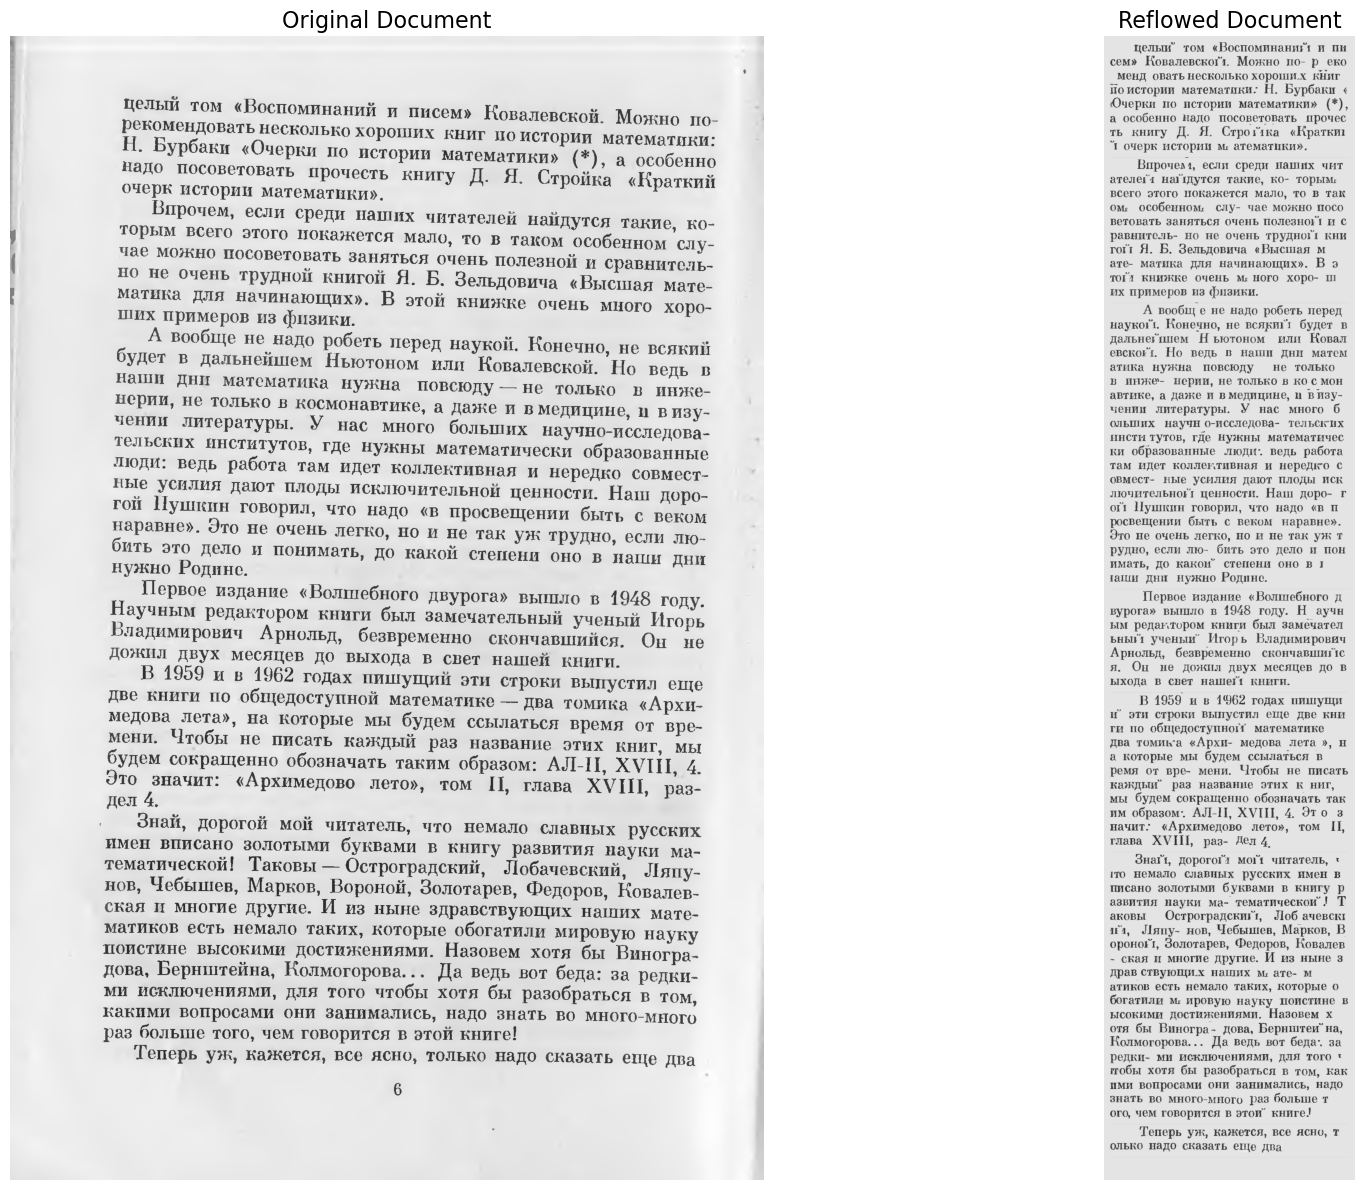

In [4]:
# Load original image
original_image = cv2.imread(image_path)
original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# Display original
axes[0].imshow(original_rgb)
axes[0].set_title('Original Document', fontsize=16)
axes[0].axis('off')

# Display reflowed
axes[1].imshow(result_rgb)
axes[1].set_title('Reflowed Document', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Display Only the Reflowed Result

For a larger view of just the reflowed document:

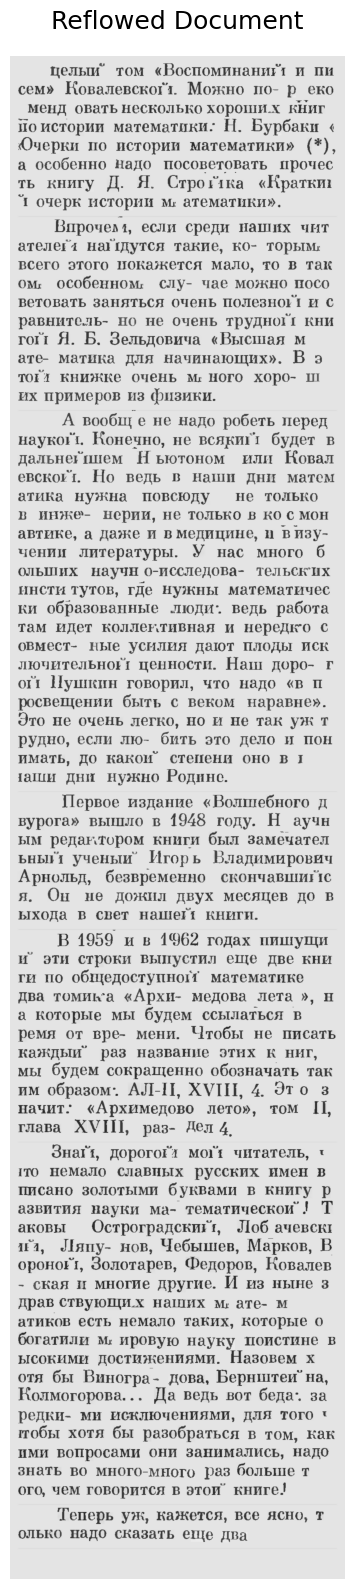

In [5]:
# Display just the reflowed result in a larger size
plt.figure(figsize=(12, 16))
plt.imshow(result_rgb)
plt.axis('off')
plt.title('Reflowed Document', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

## Save the Result

Save the reflowed document to a file:

In [6]:
# Save the result
output_path = "../output_reflowed.png"
cv2.imwrite(output_path, result_image)
print(f"Saved reflowed document to: {output_path}")

Saved reflowed document to: ../output_reflowed.png


## Process Multiple Images

You can process multiple images in a batch:

In [ ]:
# List of images to process
image_files = [
    "../images/dvurog_p007.png",
    "../images/dvurog_p011.png",
    # Add more images as needed
]

# Process each image
for img_path in image_files:
    if Path(img_path).exists():
        print(f"Processing: {img_path}")
        result = process_document(img_path)
        
        # Save with _reflowed suffix
        output_path = img_path.replace('.png', '_reflowed.png')
        cv2.imwrite(output_path, result)
        print(f"  Saved to: {output_path}")
    else:
        print(f"File not found: {img_path}")

## Advanced: Access Individual Components

You can also use individual components of the package:

In [ ]:
from ocr_reflow import find_rects, margins
from doctr.models import detection_predictor
from doctr.io import DocumentFile

# Example: Use the detection model directly
model = detection_predictor(pretrained=True)
docs = DocumentFile.from_images([image_path])
result = model(docs)

print(f"Detected {len(result[0]['words'])} word regions")

## Summary

This notebook demonstrated:

1. Basic usage of `process_document()` function
2. Displaying original and reflowed images
3. Saving reflowed documents
4. Batch processing multiple images
5. Accessing individual package components

For more information, see the [README.md](../README.md) file.